<a href="https://colab.research.google.com/github/nadisfeu/trabalhoClassPetsLLE/blob/main/trabalhoClassPets_LLE_estratifica%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

nandisfeu_the_oxford_iiit_pet_dataset_path = kagglehub.dataset_download('nandisfeu/the-oxford-iiit-pet-dataset')

print('Data source import complete.')


# **Bibliotecas**

In [ ]:
import os

os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

# bibliotecas para treino, teste e validação, modelo de regressão e avaliação do modelo
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict

# bibliotecas para avaliação de desempenho dos modelos de classificação
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.base import clone
from skimage.transform import resize
from skimage.io import imread
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score


from xgboost import XGBClassifier

# **Configurações e exploração**

In [ ]:
dataset_path = '/kaggle/input/the-oxford-iiit-pet-dataset/'
base_dir = dataset_path + 'images/images/' # Onde estão as fotos
annot_file = dataset_path + 'annotations/annotations/list.txt' #Onde estão as labels
trimap_dir = dataset_path +'annotations/annotations/trimaps' #Onde estão os trimaps
dim = 64

# 1. Carregar o mapa (DataFrame)
df = pd.read_csv(annot_file, sep=' ', comment='#', header=None,
                 names=['filename', 'class_id', 'species', 'breed_id'])

# Adicionar a extensão .jpg, pois o arquivo de texto não tem
df['filename'] = df['filename'] + '.jpg'

df['breed_name'] = df['filename'].apply(lambda x: x.rpartition('_')[0])
mapa_nomes = df[['class_id', 'breed_name']].drop_duplicates().sort_values('class_id')
lista_nomes = mapa_nomes['breed_name'].tolist()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7349 entries, 0 to 7348
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filename    7349 non-null   object
 1   class_id    7349 non-null   int64 
 2   species     7349 non-null   int64 
 3   breed_id    7349 non-null   int64 
 4   breed_name  7349 non-null   object
dtypes: int64(3), object(2)
memory usage: 287.2+ KB


In [ ]:
print("Total de imagens no DF:", len(df))
print("Raças únicas no DF:", df['breed_id'].unique())
print("Quantas raças tem:", len(df['breed_id'].unique()))
print("Quantas classes tem:", len(df['class_id'].unique()))
df.head()

Total de imagens no DF: 7349
Raças únicas no DF: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25]
Quantas raças tem: 25
Quantas classes tem: 37


,filename,class_id,species,breed_id,breed_name
0,Abyssinian_100.jpg,1,1,1,Abyssinian
1,Abyssinian_101.jpg,1,1,1,Abyssinian
2,Abyssinian_102.jpg,1,1,1,Abyssinian
3,Abyssinian_103.jpg,1,1,1,Abyssinian
4,Abyssinian_104.jpg,1,1,1,Abyssinian


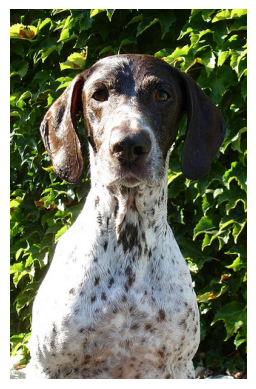

/kaggle/input/the-oxford-iiit-pet-dataset/images/images/german_shorthaired_10.jpg


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# pega uma imagem aleatoria do dataset para exemplo
caminho_img = base_dir + df['filename'][np.random.randint(0, df.shape[0])]

img = mpimg.imread(caminho_img)
plt.imshow(img)
plt.axis('off') # Opcional: remove os eixos com números
plt.show()

print(caminho_img)

In [ ]:
print(df['species'].value_counts())
print(df['class_id'].value_counts(normalize=True))

species
2    4978
1    2371
Name: count, dtype: int64
class_id
2     0.027215
4     0.027215
3     0.027215
5     0.027215
6     0.027215
37    0.027215
7     0.027215
11    0.027215
10    0.027215
17    0.027215
16    0.027215
15    0.027215
14    0.027215
18    0.027215
20    0.027215
21    0.027215
28    0.027215
26    0.027215
25    0.027215
24    0.027215
22    0.027215
29    0.027215
32    0.027215
36    0.027215
34    0.027215
30    0.027215
27    0.027215
33    0.027079
9     0.027079
19    0.027079
31    0.027079
1     0.026942
13    0.026670
23    0.026670
12    0.025854
35    0.025718
8     0.025037
Name: proportion, dtype: float64


# **Funções auxiliares**

In [ ]:
def data_species_masking(dim, base_dir, trimap_dir, df):
    data_x = []
    data_y = []

    print("Iniciando processamento com Mascaramento (Recorte)...")

    for index, row in df.iterrows():
        try:

            img_path = os.path.join(base_dir, row['filename'])
            filename_png = row['filename'].replace('.jpg', '.png')
            trimap_path = os.path.join(trimap_dir, filename_png)

            img = imread(img_path)
            trimap = imread(trimap_path, as_gray=True)


            img_resized = resize(img, (dim, dim), anti_aliasing=True, mode='reflect')
            trimap_resized = resize(trimap, (dim, dim), order=0, preserve_range=True, mode='reflect')


            mascara = np.where(trimap_resized == 1, 1, 0) # 1 onde é animal, 0 onde é fundo

            # 4. Expandir máscara para 3 canais (RGB)
            mascara_rgb = np.stack((mascara, mascara, mascara), axis=2)

            # 5. MÁGICA: Multiplicação (Recorte)
            # Onde a máscara é 0, a imagem vira preto.
            img_recortada = img_resized * mascara_rgb

            # 6. Achatar e Salvar
            img_flat = img_recortada.flatten()

            if len(img_flat) == dim * dim * 3:
                data_x.append(img_flat)
                data_y.append(row['species'])

        except Exception as e:
            print(f"Erro ao processar {row['filename']}: {e}")

    return np.array(data_x), np.array(data_y)


# **pre processamento de dados**

In [ ]:
def data_species(dim,base_dir,df):
    data_x = []
    data_y = []
    for i in range(df.shape[0]):
      #print(f"processando imagem {i} / {df['filename'][i]}")
      try:
        #leio o caminho da imagem
        img_path = base_dir + df['filename'][i]
        #faço a abertura da imagem
        img = imread(img_path)
        #redimensionamento da imagem
        img_resized = resize(img, (dim, dim), anti_aliasing=True)

        img_flat = img_resized.flatten()

        if len(img_flat) == dim * dim * 3: # Garante que tem 3 canais de cor (RGB)
                data_x.append(img_flat)
                data_y.append(df['species'][i])

      except:
        print(f"Erro ao processar a imagem {img_path}")

    X = np.array(data_x)
    y = np.array(data_y)
    return X,y

In [ ]:
def data_estratificado_binario(dim, base_dir, df, col_raca='class_id', col_especie='species'):
    """
    Carrega dataset para classificação BINÁRIA (Gato vs Cachorro).
    Balanceia as classes aumentando as raças de gato manualmente.
    Retorna y com 0 (Gato) e 1 (Cachorro), e devolve as imagens já recortadas pelo trimap.
    """

    # --- 1. CARREGAMENTO INICIAL ---
    data_x = []
    data_y_species = [] # Guardamos a espécie (Alvo Final)
    data_y_breed = []   # Guardamos a raça (Para calcular o balanceamento)

    print(f"Carregando {len(df)} imagens... (Pode demorar um pouco)")

    # Iteramos pelo índice para garantir alinhamento
    for idx in df.index:
        try:
            filename = df.loc[idx, 'filename']
            img_path = base_dir + filename
            filename_png = filename.replace('.jpg', '.png')
            trimap_path = os.path.join(trimap_dir, filename_png)

            img = imread(img_path)
            trimap = imread(trimap_path, as_gray=True)

            img_resized = resize(img, (dim, dim), anti_aliasing=True)
            trimap_resized = resize(trimap, (dim, dim), order=0, preserve_range=True, mode='reflect')

            mascara = np.where(trimap_resized == 1, 1, 0) # 1 onde é animal, 0 onde é fundo
            mascara_rgb = np.stack((mascara, mascara, mascara), axis=2)
            img_recortada = img_resized * mascara_rgb

            img_flat = img_recortada.flatten()

            # Filtro RGB estrito
            if len(img_flat) == dim * dim * 3:
                data_x.append(img_flat)
                data_y_species.append(df.loc[idx, col_especie])
                data_y_breed.append(df.loc[idx, col_raca])

        except Exception as e:
            # print(f"Erro em {filename}: {e}")
            pass

    # Converte para numpy arrays temporários
    X_raw = np.array(data_x)
    y_species_raw = np.array(data_y_species)
    y_breed_raw = np.array(data_y_breed)

    print(f"Dados Brutos Carregados: {X_raw.shape}")
    print("Iniciando balanceamento manual Gato vs. Cachorro...")

    # --- 2. LÓGICA DE BALANCEAMENTO HÍBRIDO ---

    # Identifica IDs das espécies
    # Assumindo pelo seu df: 1 = Gato (Minoria), 2 = Cachorro (Maioria)
    vals, counts = np.unique(y_species_raw, return_counts=True)
    id_minoria = vals[np.argmin(counts)] # Deve ser 1 (Gato)
    id_maioria = vals[np.argmax(counts)] # Deve ser 2 (Cachorro)

    total_maioria = np.max(counts) # Ex: 5000

    # Identifica quais RAÇAS pertencem à minoria (Gatos)
    racas_minoria = np.unique(y_breed_raw[y_species_raw == id_minoria])
    racas_maioria = np.unique(y_breed_raw[y_species_raw == id_maioria])

    # Calcula meta por raça de gato: (Total Cães) / (12 Raças de Gato)
    # Ex: 5000 / 12 = ~416 fotos por raça
    meta_por_raca = int(total_maioria / len(racas_minoria))

    indices_finais = []

    # A. Processa GATOS (Minoria -> Aumentar)
    for raca in racas_minoria:
        # Pega índices onde aparece essa raça
        indices_desta_raca = np.where(y_breed_raw == raca)[0]

        # Sorteia com reposição (duplica) até atingir a meta
        if len(indices_desta_raca) > 0:
            indices_escolhidos = np.random.choice(indices_desta_raca, size=meta_por_raca, replace=True)
            indices_finais.append(indices_escolhidos)

    # B. Processa CACHORROS (Maioria -> Manter Original)
    for raca in racas_maioria:
        indices_desta_raca = np.where(y_breed_raw == raca)[0]
        # Mantém original
        indices_finais.append(indices_desta_raca)

    # --- 3. MONTAGEM FINAL ---
    # Junta todos os índices e embaralha
    todos_indices = np.concatenate(indices_finais)
    np.random.shuffle(todos_indices)

    X_final = X_raw[todos_indices]
    y_final_species = y_species_raw[todos_indices]

    # Ajuste final: Converter 1 e 2 para 0 e 1 (Padrão Binário)
    # Se Gato=1 e Cão=2 -> Gato=0 e Cão=1
    y_final_binario = np.where(y_final_species == id_minoria, 0, 1)

    print("-" * 30)
    print(f"Shape Final X: {X_final.shape}")
    print(f"Shape Final y: {y_final_binario.shape}")

    unique, counts = np.unique(y_final_binario, return_counts=True)
    dist = dict(zip(unique, counts))
    print(f"Distribuição Final: {dist}")
    print("0 = Gato, 1 = Cachorro")
    print("-" * 30)

    return np.array(X_final), np.array(y_final_binario)

In [ ]:
def data_estratificado_multiclasse(dim, base_dir, df, col_raca='class_id', col_especie='species'):
    """
    Carrega dataset para classificação MULTICLASSE (Raças).

    LÓGICA DE BALANCEAMENTO (HÍBRIDA):
    - O objetivo é equalizar as ESPÉCIES (Total Gatos == Total Cachorros).
    - Como existem menos raças de gato, cada raça de gato terá mais fotos individualmente
      do que cada raça de cachorro.
    - O 'y' retornado contém o ID da RAÇA (0 a 36).
    """

    # --- 1. CARREGAMENTO INICIAL ---
    data_x = []
    data_y_species = [] # Precisamos da espécie para calcular o balanceamento
    data_y_breed = []   # Precisamos da raça para ser a SAÍDA (Target)

    print(f"Carregando {len(df)} imagens... (Pode demorar um pouco)")

    for idx in df.index:
        try:
            filename = df.loc[idx, 'filename']
            # Ajuste de path seguro
            img_path = os.path.join(base_dir, filename)
            filename_png = filename.replace('.jpg', '.png')
            trimap_path = os.path.join(trimap_dir, filename_png)

            img = imread(img_path)
            trimap = imread(trimap_path, as_gray=True)

            img_resized = resize(img, (dim, dim), anti_aliasing=True)
            trimap_resized = resize(trimap, (dim, dim), order=0, preserve_range=True, mode='reflect')

            mascara = np.where(trimap_resized == 1, 1, 0)
            mascara_rgb = np.stack((mascara, mascara, mascara), axis=2)
            img_recortada = img_resized * mascara_rgb

            img_flat = img_recortada.flatten()

            if len(img_flat) == dim * dim * 3:
                data_x.append(img_flat)
                data_y_species.append(df.loc[idx, col_especie]) # Salva Espécie (Lógica)
                data_y_breed.append(df.loc[idx, col_raca])      # Salva Raça (Saída)

        except Exception as e:
            # print(f"Erro: {e}")
            pass

    # Converte para numpy arrays temporários
    X_raw = np.array(data_x)
    y_species_raw = np.array(data_y_species)
    y_breed_raw = np.array(data_y_breed)

    print(f"Dados Brutos: {X_raw.shape}")
    print("Iniciando balanceamento (Total Gatos == Total Cachorros)...")

    # --- 2. LÓGICA DE BALANCEAMENTO HÍBRIDO (Idêntica à sua função binária) ---

    # Identifica IDs das espécies e contagens
    vals, counts = np.unique(y_species_raw, return_counts=True)

    # Assume-se que a minoria é Gato (ID 1 geralmente no dataset Oxford, mas verificamos via argmin)
    id_minoria = vals[np.argmin(counts)] # Gato
    id_maioria = vals[np.argmax(counts)] # Cachorro

    total_maioria = np.max(counts) # Ex: 4990 Cachorros

    # Identifica quais RAÇAS pertencem à minoria e maioria
    racas_minoria = np.unique(y_breed_raw[y_species_raw == id_minoria]) # Raças de Gato
    racas_maioria = np.unique(y_breed_raw[y_species_raw == id_maioria]) # Raças de Cachorro

    # A MÁGICA: Calcula meta para raças de gato para que a soma delas empate com os cães
    # Ex: Se tem 5000 cães e 12 raças de gato -> 5000 / 12 = ~416 gatos por raça
    meta_por_raca_minoria = int(total_maioria / len(racas_minoria))

    indices_finais = []

    # A. Processa GATOS (Minoria -> Aumentar/Upsampling)
    for raca in racas_minoria:
        indices_desta_raca = np.where(y_breed_raw == raca)[0]

        if len(indices_desta_raca) > 0:
            # Sorteia com reposição até atingir a meta inflada
            indices_escolhidos = np.random.choice(indices_desta_raca, size=meta_por_raca_minoria, replace=True)
            indices_finais.append(indices_escolhidos)

    # B. Processa CACHORROS (Maioria -> Manter Original)
    # AQUI ESTÁ A DIFERENÇA DO OUTRO CÓDIGO: Não inflamos cachorros, mantemos natural.
    for raca in racas_maioria:
        indices_desta_raca = np.where(y_breed_raw == raca)[0]
        indices_finais.append(indices_desta_raca) # Mantém original

    # --- 3. MONTAGEM FINAL ---
    todos_indices = np.concatenate(indices_finais)
    np.random.shuffle(todos_indices)

    X_final = X_raw[todos_indices]

    # MUDANÇA CRUCIAL AQUI:
    # Retornamos y_breed (0..36) em vez de y_species (0..1)
    y_final_breed = y_breed_raw[todos_indices]

    # Apenas para conferência visual no print:
    y_final_species_check = y_species_raw[todos_indices]
    unique, counts = np.unique(y_final_species_check, return_counts=True)

    print("-" * 30)
    print(f"Shape Final X: {X_final.shape}")
    print(f"Shape Final y (Raças): {y_final_breed.shape}")
    print(f"Conferência de Espécies (Gato vs Cão): {dict(zip(unique, counts))}")
    print("-" * 30)

    return np.array(X_final), np.array(y_final_breed)

In [ ]:
def aplicar_lle(data_x, n_components=30, n_neighbors=30):
    """
    Recebe os dados brutos e retorna as features extraídas pelo LLE.

    Parâmetros:
    - data_x: Lista ou array com as imagens achatadas.
    - n_components: Número de features de saída (ex: 30 para treino).
    - n_neighbors: Número de vizinhos (geometria local).

    Retorna:
    - X_lle: Array numpy com formato (N_amostras, n_components)
    """

    # 1. Garantir formato Numpy
    X = np.array(data_x)
    print(f"Iniciando LLE em {len(X)} amostras...")

    # 2. Normalização (Obrigatória para LLE)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 3. LLE
    # n_jobs=-1 usa todos os núcleos da CPU para ser mais rápido
    lle = LocallyLinearEmbedding(
        n_neighbors=n_neighbors,
        n_components=n_components,
        method='standard',
        n_jobs=-1
    )

    X_lle = lle.fit_transform(X_scaled)

    print(f"LLE Concluído. Shape final: {X_lle.shape}")
    return X_lle

# **Classificador binario**

In [ ]:
X,y = data_species(dim,base_dir,df)
print(f'X {X.shape}; y {y.shape}')

X (7346, 12288); y (7346,)


In [ ]:
X,y = data_estratificado_binario(dim, base_dir, df)
print(f'X {X.shape}; y {y.shape}')

Carregando 7349 imagens... (Pode demorar um pouco)
Dados Brutos Carregados: (7346, 12288)
Iniciando balanceamento manual Gato vs. Cachorro...
------------------------------
Shape Final X: (9946, 12288)
Shape Final y: (9946,)
Distribuição Final: {0: 4968, 1: 4978}
0 = Gato, 1 = Cachorro
------------------------------
X (9946, 12288); y (9946,)


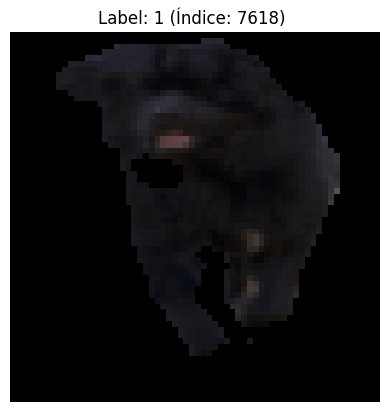

In [ ]:
index = random.randint(0, len(X)-1)
imagem_achatada = X[index]
rotulo = y[index]

# REVERTER O PROCESSO:
imagem_reconstruida = imagem_achatada.reshape(dim, dim, 3)

plt.imshow(imagem_reconstruida)
plt.title(f"Label: {rotulo} (Índice: {index}) ")
plt.axis('off')
plt.show()

LLE: LocallyLinearEmbedding

In [ ]:
X_lle = aplicar_lle(X,n_neighbors = 60, n_components=45)
#X_transformado = aplicar_e_visualizar_lle(data_x, data_y_species, n_neighbors=30)

Iniciando LLE em 9946 amostras...
LLE Concluído. Shape final: (9946, 45)


In [ ]:
print(f'X {X_lle.shape}; y {y.shape}')

X (9946, 45); y (9946,)


# teste binario: xgBoost com LLE

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_lle,y,
                                       test_size=0.2, # parâmetro da divisão 80/20
                                       random_state=42)

print("Valores únicos no y_test:", np.unique(y_test))
print("Matriz de features do dataset de treino:\tformato ", X_train.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test.shape)

Valores únicos no y_test: [0 1]
Matriz de features do dataset de treino:	formato  (7956, 45)
Vetor de labels do dataset de treino:		formato  (7956,)
Matriz de features do dataset de teste:		formato  (1990, 45)
Vetor de labels do dataset de teste:		formato  (1990,)


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,      # Com GPU, podemos ousar e usar mais árvores
    learning_rate=0.1,
    max_depth=6,

    device='cuda',         # Diz para usar a GPU (CUDA)
    tree_method='hist',    # O método 'hist' é o mais otimizado para GPU

    random_state=42
)

xgb_model.fit(
    X_train,
    y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
# 3. Previsão
print("Fazendo previsões...")
y_pred = xgb_model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Acurácia XGBoost: {acc:.2%}")


print(classification_report(y_test, y_pred))

Fazendo previsões...
Acurácia XGBoost: 84.27%
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       988
           1       0.85      0.83      0.84      1002

    accuracy                           0.84      1990
   macro avg       0.84      0.84      0.84      1990
weighted avg       0.84      0.84      0.84      1990



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [15:49:20] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


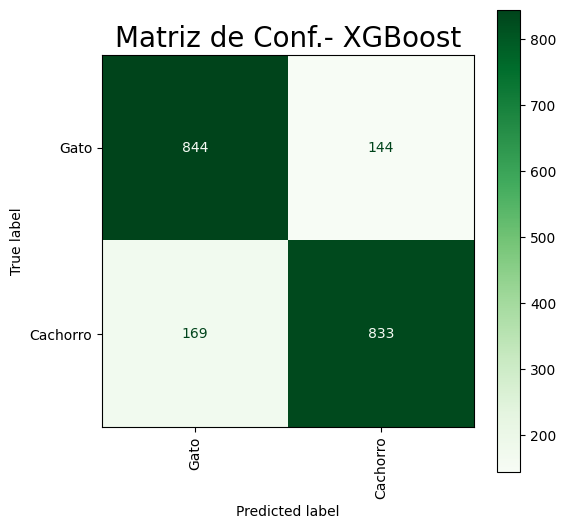

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap='Greens', # Mudei para verde para diferenciar do RF
    display_labels=['Gato', 'Cachorro'],
    #normalize='true',
    xticks_rotation='vertical',
    #values_format='.2f'
)

plt.title("Matriz de Conf.- XGBoost", fontsize=20)
plt.show()

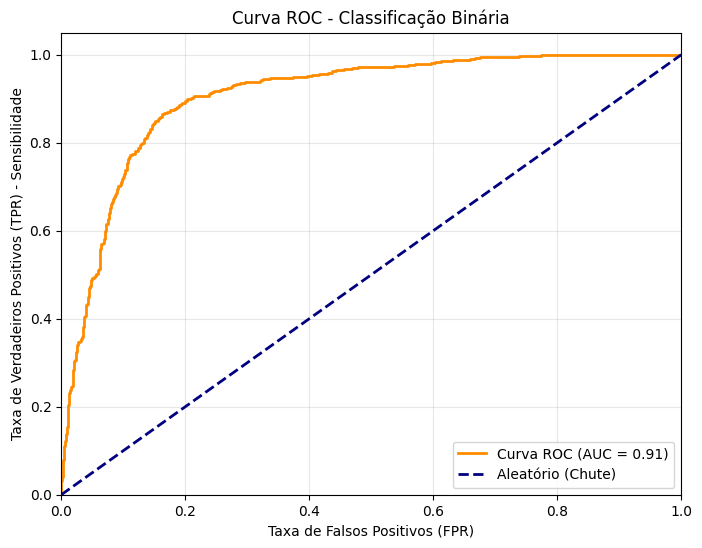

In [ ]:
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# 2. Calcular FPR, TPR e limiares
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 3. Calcular a Área Sob a Curva (AUC)
roc_auc = auc(fpr, tpr)

# 4. Plotar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatório (Chute)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Sensibilidade')
plt.title('Curva ROC - Classificação Binária')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

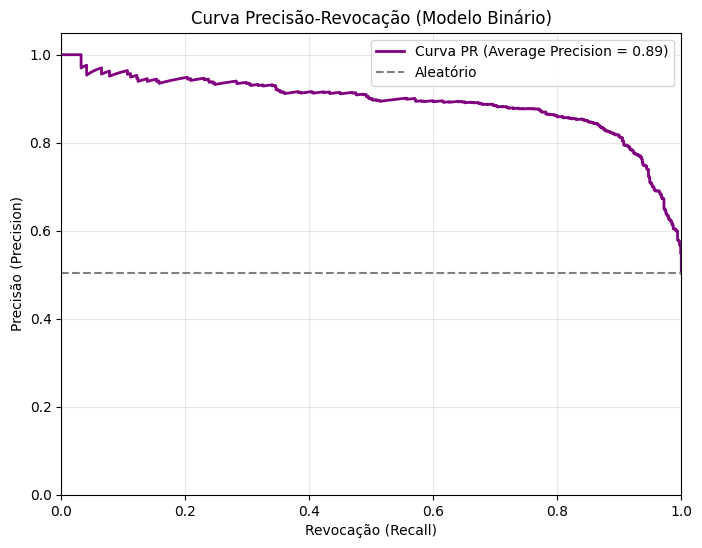

In [ ]:

# 1. Obter as probabilidades da classe Positiva (1)
# O modelo retorna [prob_classe_0, prob_classe_1]. Pegamos a coluna 1.
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# 2. Calcular os pontos da curva
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# 3. Calcular a "Average Precision" (AP)
# AP resume a curva em um único número (quanto mais perto de 1.0, melhor)
ap_score = average_precision_score(y_test, y_probs)

# 4. Plotar
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2,
         label=f'Curva PR (Average Precision = {ap_score:.2f})')

# Adiciona linha de base (frequência da classe positiva)
no_skill = len(y_test[y_test==1]) / len(y_test)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='gray', label='Aleatório')

plt.xlabel('Revocação (Recall)')
plt.ylabel('Precisão (Precision)')
plt.title('Curva Precisão-Revocação (Modelo Binário)')
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

# Limpeza de variaveis

In [ ]:
del X_train, X_test, y_train, y_test,y_pred, fpr, tpr, thresholds,roc_auc,

# class multiclasse: xgBoost

In [ ]:
X,y = data_estratificado_multiclasse(dim, base_dir, df)
print(f'X {X.shape}; y {y.shape}')

Carregando 7349 imagens... (Pode demorar um pouco)
Dados Brutos: (7346, 12288)
Iniciando balanceamento (Total Gatos == Total Cachorros)...
------------------------------
Shape Final X: (9946, 12288)
Shape Final y (Raças): (9946,)
Conferência de Espécies (Gato vs Cão): {1: 4968, 2: 4978}
------------------------------
X (9946, 12288); y (9946,)


In [ ]:
X_lle = aplicar_lle(X,n_neighbors = 60, n_components=45)
print(f'X {X_lle.shape}; y {y.shape}')

Iniciando LLE em 9946 amostras...
LLE Concluído. Shape final: (9946, 45)
X (9946, 45); y (9946,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_lle,y,
                                       test_size=0.2, # parâmetro da divisão 80/20
                                       random_state=42)




In [ ]:
y_train = y_train - 1
y_test = y_test - 1

print("Valores únicos no y_test:", np.unique(y_test))
print("Matriz de features do dataset de treino:\tformato ", X_train.shape)
print("Vetor de labels do dataset de treino:\t\tformato ", y_train.shape)
print("Matriz de features do dataset de teste:\t\tformato ", X_test.shape)
print("Vetor de labels do dataset de teste:\t\tformato ", y_test.shape)

Valores únicos no y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36]
Matriz de features do dataset de treino:	formato  (7956, 45)
Vetor de labels do dataset de treino:		formato  (7956,)
Matriz de features do dataset de teste:		formato  (1990, 45)
Vetor de labels do dataset de teste:		formato  (1990,)


In [ ]:


xgb_model = XGBClassifier(
    n_estimators=200,      # Com GPU, podemos ousar e usar mais árvores
    learning_rate=0.1,
    max_depth=6,
    objective='multi:softmax',
    num_class=37,

    device='cuda',         # Diz para usar a GPU (CUDA)
    tree_method='hist',    # O método 'hist' é o mais otimizado para GPU

    random_state=42
)


In [ ]:
xgb_model.fit(
    X_train,
    y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=37,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Acurácia XGBoost: {acc:.2%}")

print("\nRelatório Detalhado:")
try:
    print(classification_report(y_test, y_pred, target_names=lista_nomes))
except:
    print(classification_report(y_test, y_pred))

Acurácia XGBoost: 43.12%

Relatório Detalhado:
                            precision    recall  f1-score   support

                Abyssinian       0.67      0.80      0.73        69
          american_bulldog       0.10      0.05      0.07        41
 american_pit_bull_terrier       0.07      0.04      0.05        47
              basset_hound       0.10      0.04      0.06        50
                    beagle       0.05      0.09      0.07        46
                    Bengal       0.64      0.77      0.70        73
                    Birman       0.68      0.83      0.75        89
                    Bombay       0.71      0.94      0.81        83
                     boxer       0.11      0.07      0.08        46
         British_Shorthair       0.71      0.81      0.76        86
                 chihuahua       0.00      0.00      0.00        36
              Egyptian_Mau       0.73      0.81      0.77        86
    english_cocker_spaniel       0.04      0.03      0.03        36


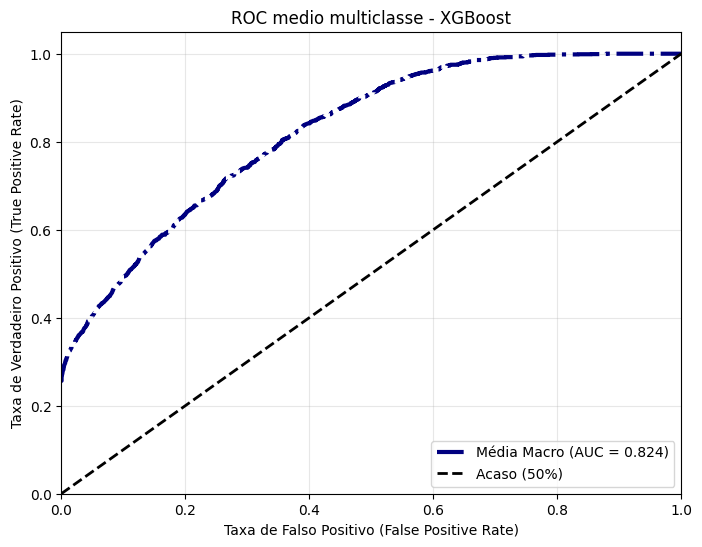

In [ ]:
# --- 1. PREPARAÇÃO (One-vs-Rest) ---
# Identifica as classes e binariza o teste
classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

# Pega as probabilidades
y_score = xgb_model.predict_proba(X_test)

# --- 2. CÁLCULO DA MÉDIA MACRO ---
# Primeiro, precisamos calcular a curva de CADA classe para poder fazer a média
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

# Agora agregamos todos os pontos de False Positive Rate
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolamos todas as curvas ROC nesses pontos comuns
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Tiramos a média
mean_tpr /= n_classes

# Calculamos a Área Sob a Curva (AUC) da média
macro_auc = auc(all_fpr, mean_tpr)

# --- 3. PLOTAGEM LIMPA ---
plt.figure(figsize=(8, 6))

plt.plot(
    all_fpr,
    mean_tpr,
    color='navy',
    linestyle='-.',
    linewidth=3,
    label=f'Média Macro (AUC = {macro_auc:.3f})'
)

# Linha de referência (Chute Aleatório - 50%)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Acaso (50%)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiro Positivo (True Positive Rate)')
plt.title('ROC medio multiclasse - XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

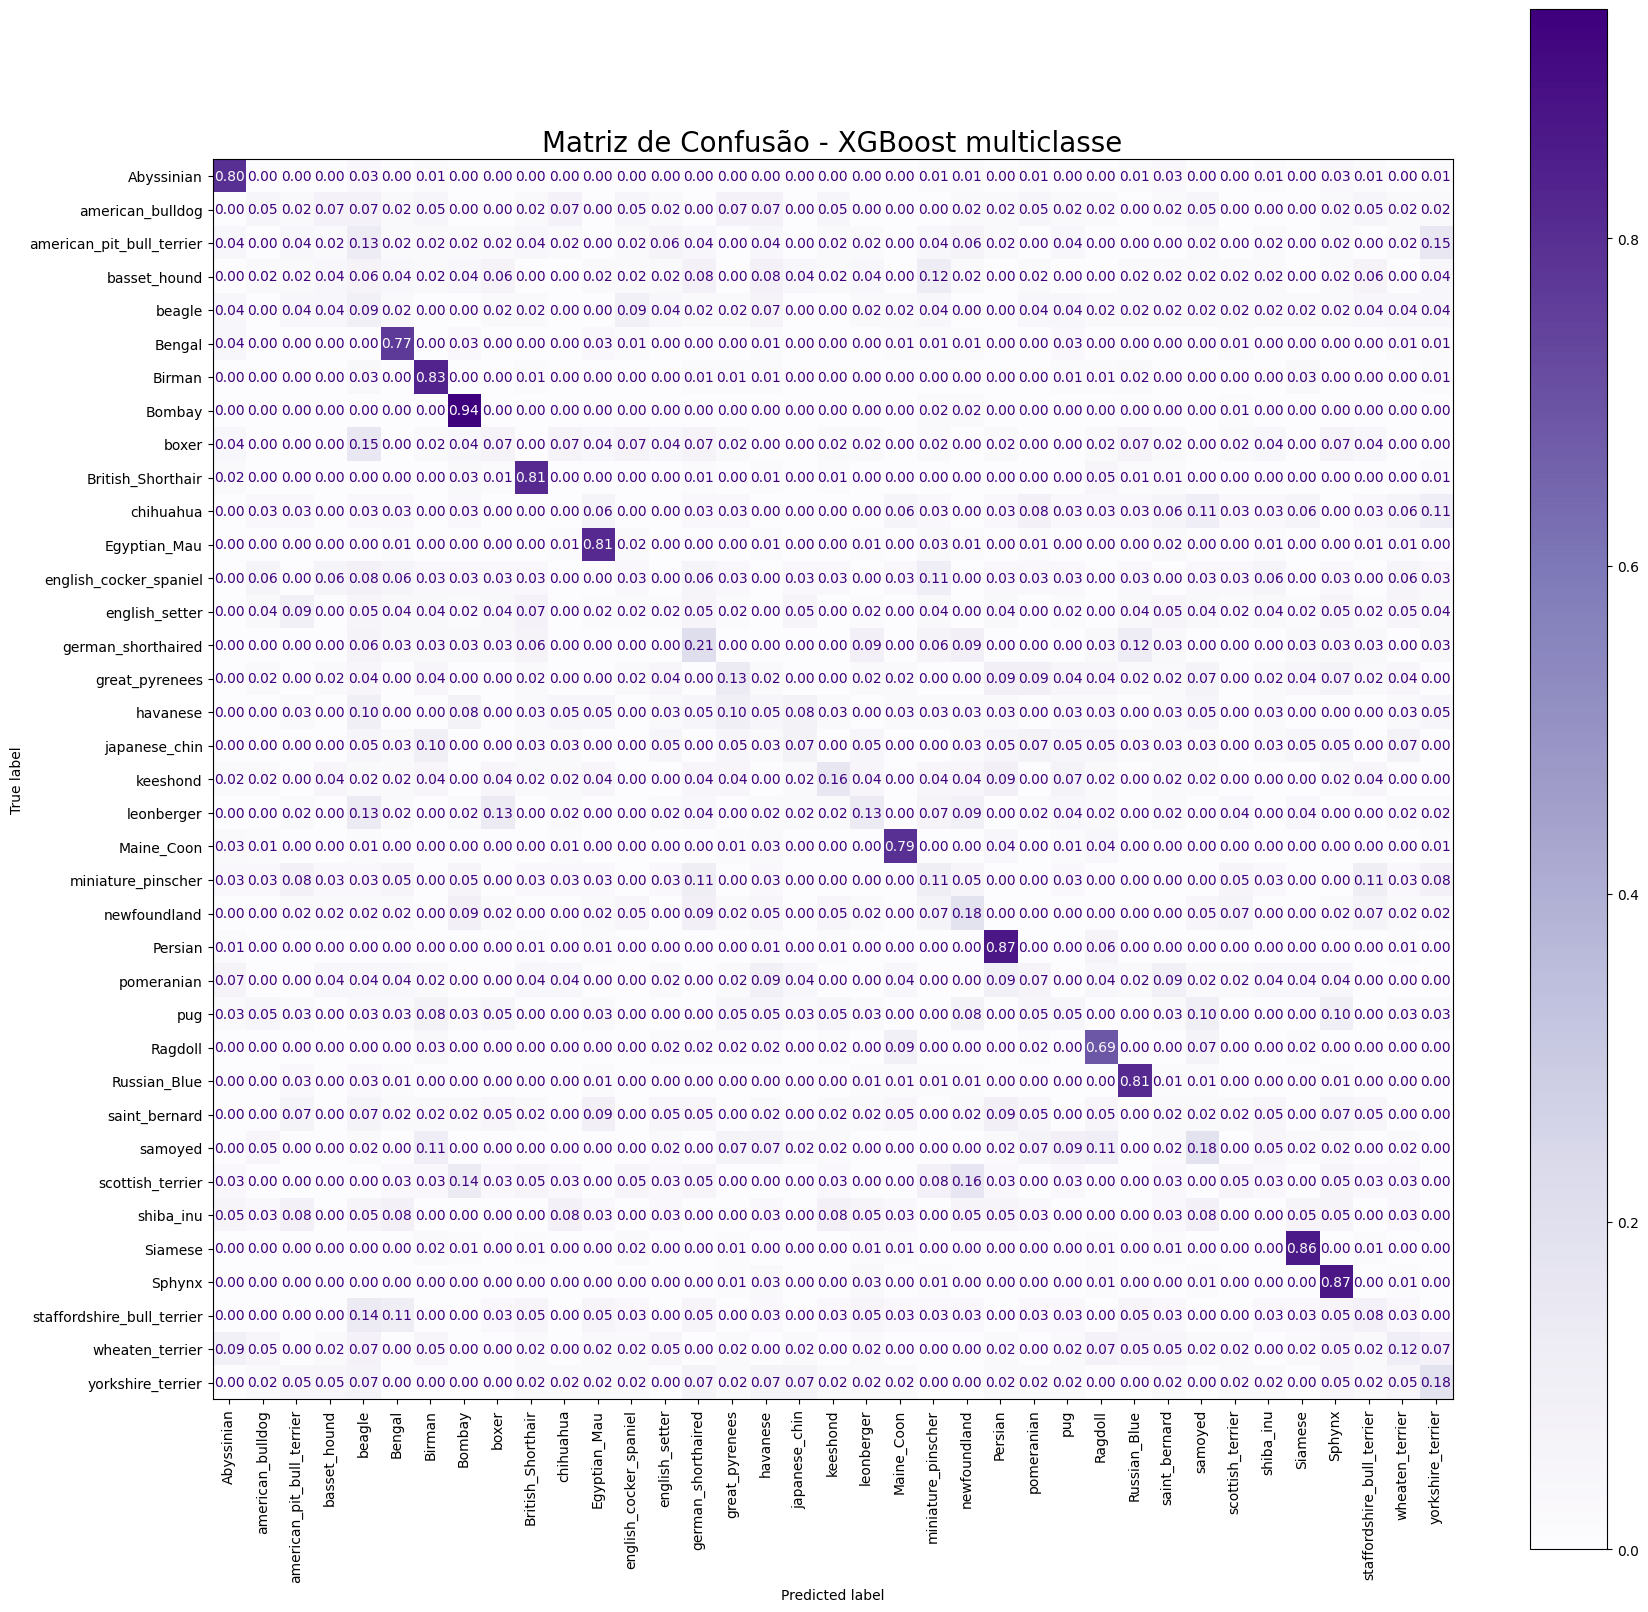

In [ ]:
# 5. Visualizar onde ele acertou mais
fig, ax = plt.subplots(figsize=(20, 20))

# Se tiver a lista de nomes, usamos ela para ficar bonito
labels_display = lista_nomes if 'lista_nomes' in locals() else le.classes_

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=labels_display,
    ax=ax,
    cmap='Purples', # Mudei para verde para diferenciar do RF
    normalize='true',
    xticks_rotation='vertical',
    values_format='.2f'
)

plt.title("Matriz de Confusão - XGBoost multiclasse", fontsize=20)
plt.show()

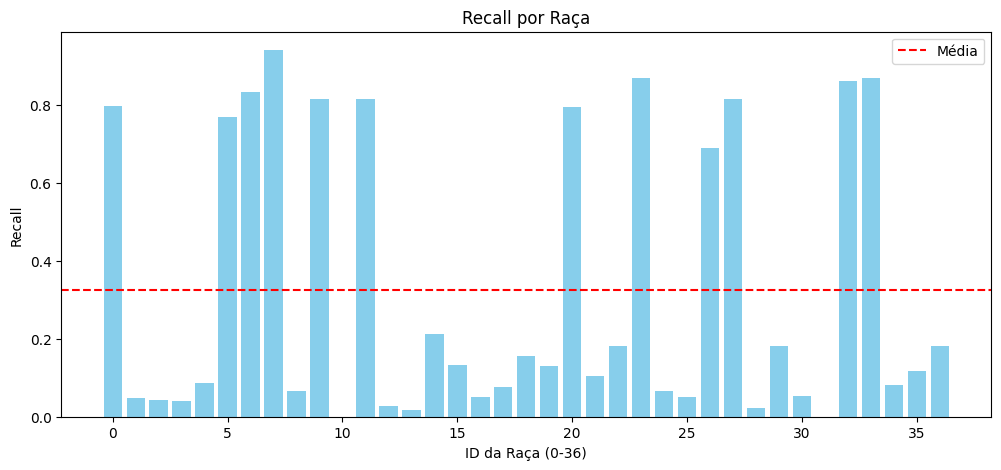

A raça mais difícil foi a ID 10 com 0.00% de recall.


In [ ]:
recalls_por_classe = recall_score(y_test, y_pred, average=None)

# Vamos plotar para ver visualmente
plt.figure(figsize=(12, 5))
plt.bar(range(len(recalls_por_classe)), recalls_por_classe, color='skyblue')
plt.xlabel('ID da Raça (0-36)')
plt.ylabel('Recall')
plt.title('Recall por Raça')
plt.axhline(y=np.mean(recalls_por_classe), color='r', linestyle='--', label='Média')
plt.legend()
plt.show()

# Dica: Para saber qual é a raça com pior recall:
pior_raca_id = np.argmin(recalls_por_classe)
print(f"A raça mais difícil foi a ID {pior_raca_id} com {recalls_por_classe[pior_raca_id]:.2%} de recall.")

In [ ]:
def visualizar_erros(X_pixels, y_real, y_pred, qtd=10):
    """
    Plota imagens que o modelo errou.
    """
    indices_erros = np.where(y_pred != y_real)[0]

    print(f"Total de erros encontrados: {len(indices_erros)}")

    if len(indices_erros) == 0:
        print("Parabéns! Seu modelo não errou nada (ou algo está errado no código).")
        return

    indices_para_mostrar = np.random.choice(indices_erros, size=min(qtd, len(indices_erros)), replace=False)

    plt.figure(figsize=(15, 8))

    for i, idx in enumerate(indices_para_mostrar):
        plt.subplot(2, 5, i + 1) # Cria um grid de 2 linhas x 5 colunas

        # Recupera a imagem achatada e redimensiona para (128, 128, 3)
        img = X_pixels[idx].reshape(dim, dim, 3)

        # Como normalizamos ou o fundo é preto, às vezes precisa garantir range 0-1 para exibir
        # Se sua imagem estiver entre 0-255, divida por 255. Se já for float 0-1, deixe assim.
        if img.max() > 1.1:
            img = img / 255.0

        plt.imshow(img)
        plt.title(f"Real: {y_real[idx]}\nPred: {y_pred[idx]}", color='red', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Total de erros encontrados: 1132


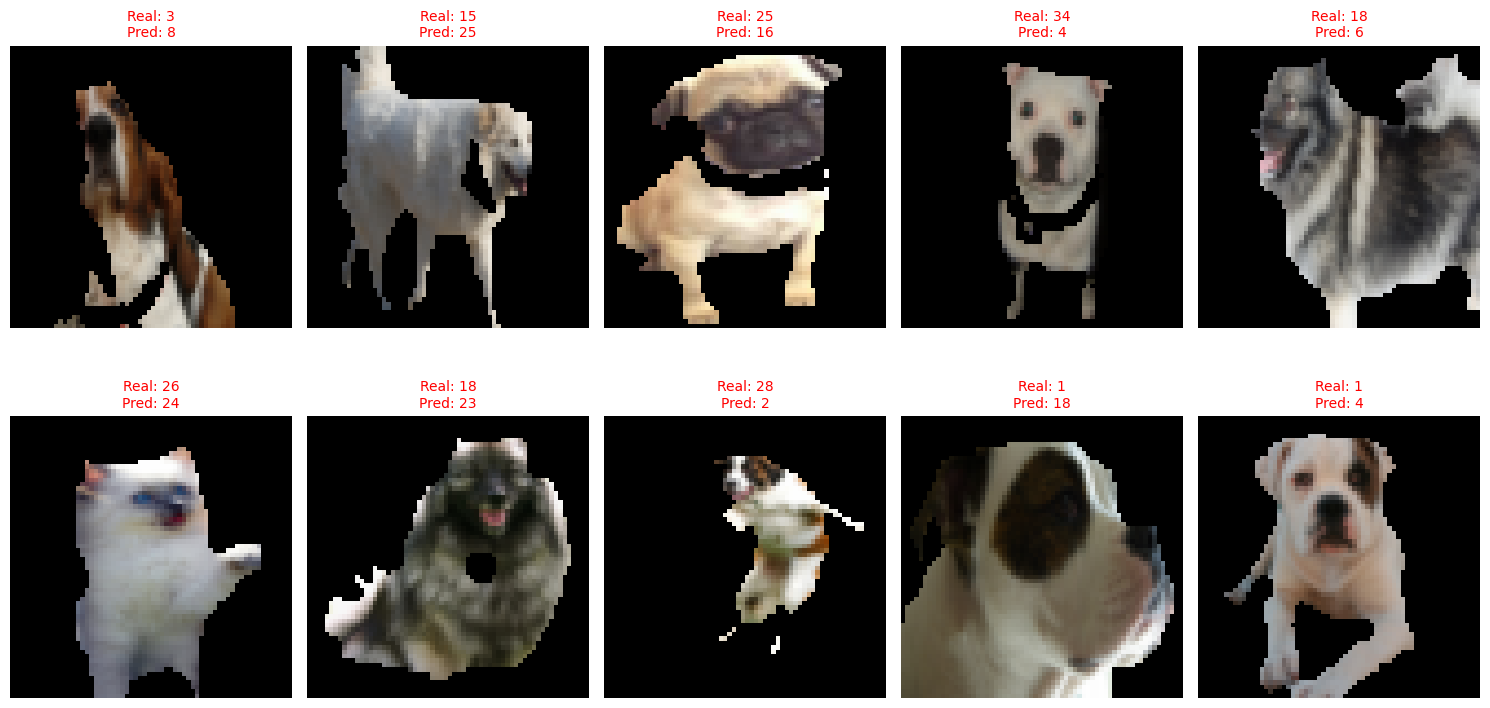

In [ ]:
_, X_test_pixels, _, _ = train_test_split(X, y, test_size=0.2, random_state=42)

# --- CHAMANDO A FUNÇÃO ---
# Certifique-se de passar o X_test_pixels (imagens), não o X_test (LLE)
visualizar_erros(X_test_pixels, y_test, y_pred, qtd=10)

# **Pontuação extra:**

o OVO seria inviavel computacionamente por causa da quantidade de classes, então a melhor opção é usar o OVR

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier


model_ovr = OneVsRestClassifier(XGBClassifier(n_jobs=-1, random_state=42))

model_ovr.fit(X_train, y_train)

y_pred = model_ovr.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia XGBoost: {acc:.2%}")

print("\nRelatório Detalhado:")
try:
    print(classification_report(y_test, y_pred, target_names=lista_nomes))
except:
    print(classification_report(y_test, y_pred))

Acurácia XGBoost: 43.02%

Relatório Detalhado:
                            precision    recall  f1-score   support

                Abyssinian       0.63      0.80      0.71        69
          american_bulldog       0.13      0.10      0.11        41
 american_pit_bull_terrier       0.11      0.09      0.10        47
              basset_hound       0.04      0.02      0.03        50
                    beagle       0.04      0.04      0.04        46
                    Bengal       0.66      0.79      0.72        73
                    Birman       0.69      0.83      0.76        89
                    Bombay       0.69      0.93      0.79        83
                     boxer       0.17      0.11      0.13        46
         British_Shorthair       0.72      0.79      0.76        86
                 chihuahua       0.07      0.06      0.06        36
              Egyptian_Mau       0.75      0.81      0.78        86
    english_cocker_spaniel       0.00      0.00      0.00        36


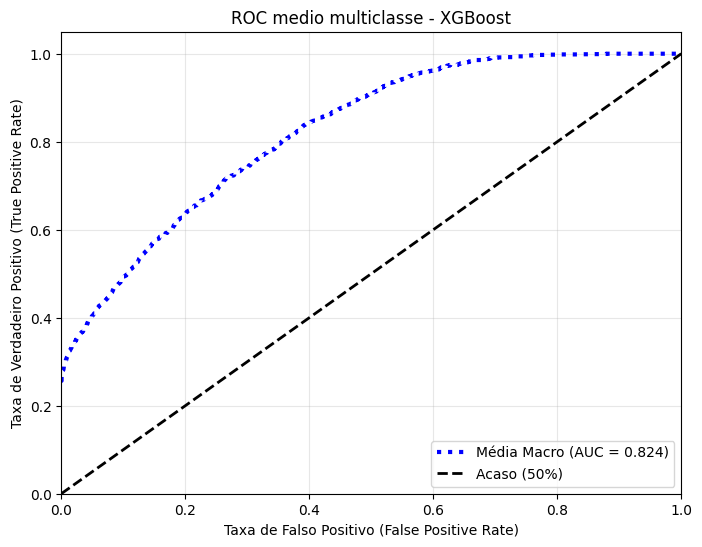

In [ ]:
# --- 1. PREPARAÇÃO (One-vs-Rest) ---
# Identifica as classes e binariza o teste
classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

# Pega as probabilidades
y_score = xgb_model.predict_proba(X_test)

# --- 2. CÁLCULO DA MÉDIA MACRO ---
# Primeiro, precisamos calcular a curva de CADA classe para poder fazer a média
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

# Agora agregamos todos os pontos de False Positive Rate
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolamos todas as curvas ROC nesses pontos comuns
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Tiramos a média
mean_tpr /= n_classes

# Calculamos a Área Sob a Curva (AUC) da média
macro_auc = auc(all_fpr, mean_tpr)

# --- 3. PLOTAGEM LIMPA ---
plt.figure(figsize=(8, 6))

plt.plot(
    all_fpr,
    mean_tpr,
    color='blue',
    linestyle=':',
    linewidth=3,
    label=f'Média Macro (AUC = {macro_auc:.3f})'
)

# Linha de referência (Chute Aleatório - 50%)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Acaso (50%)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiro Positivo (True Positive Rate)')
plt.title('ROC medio multiclasse - XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

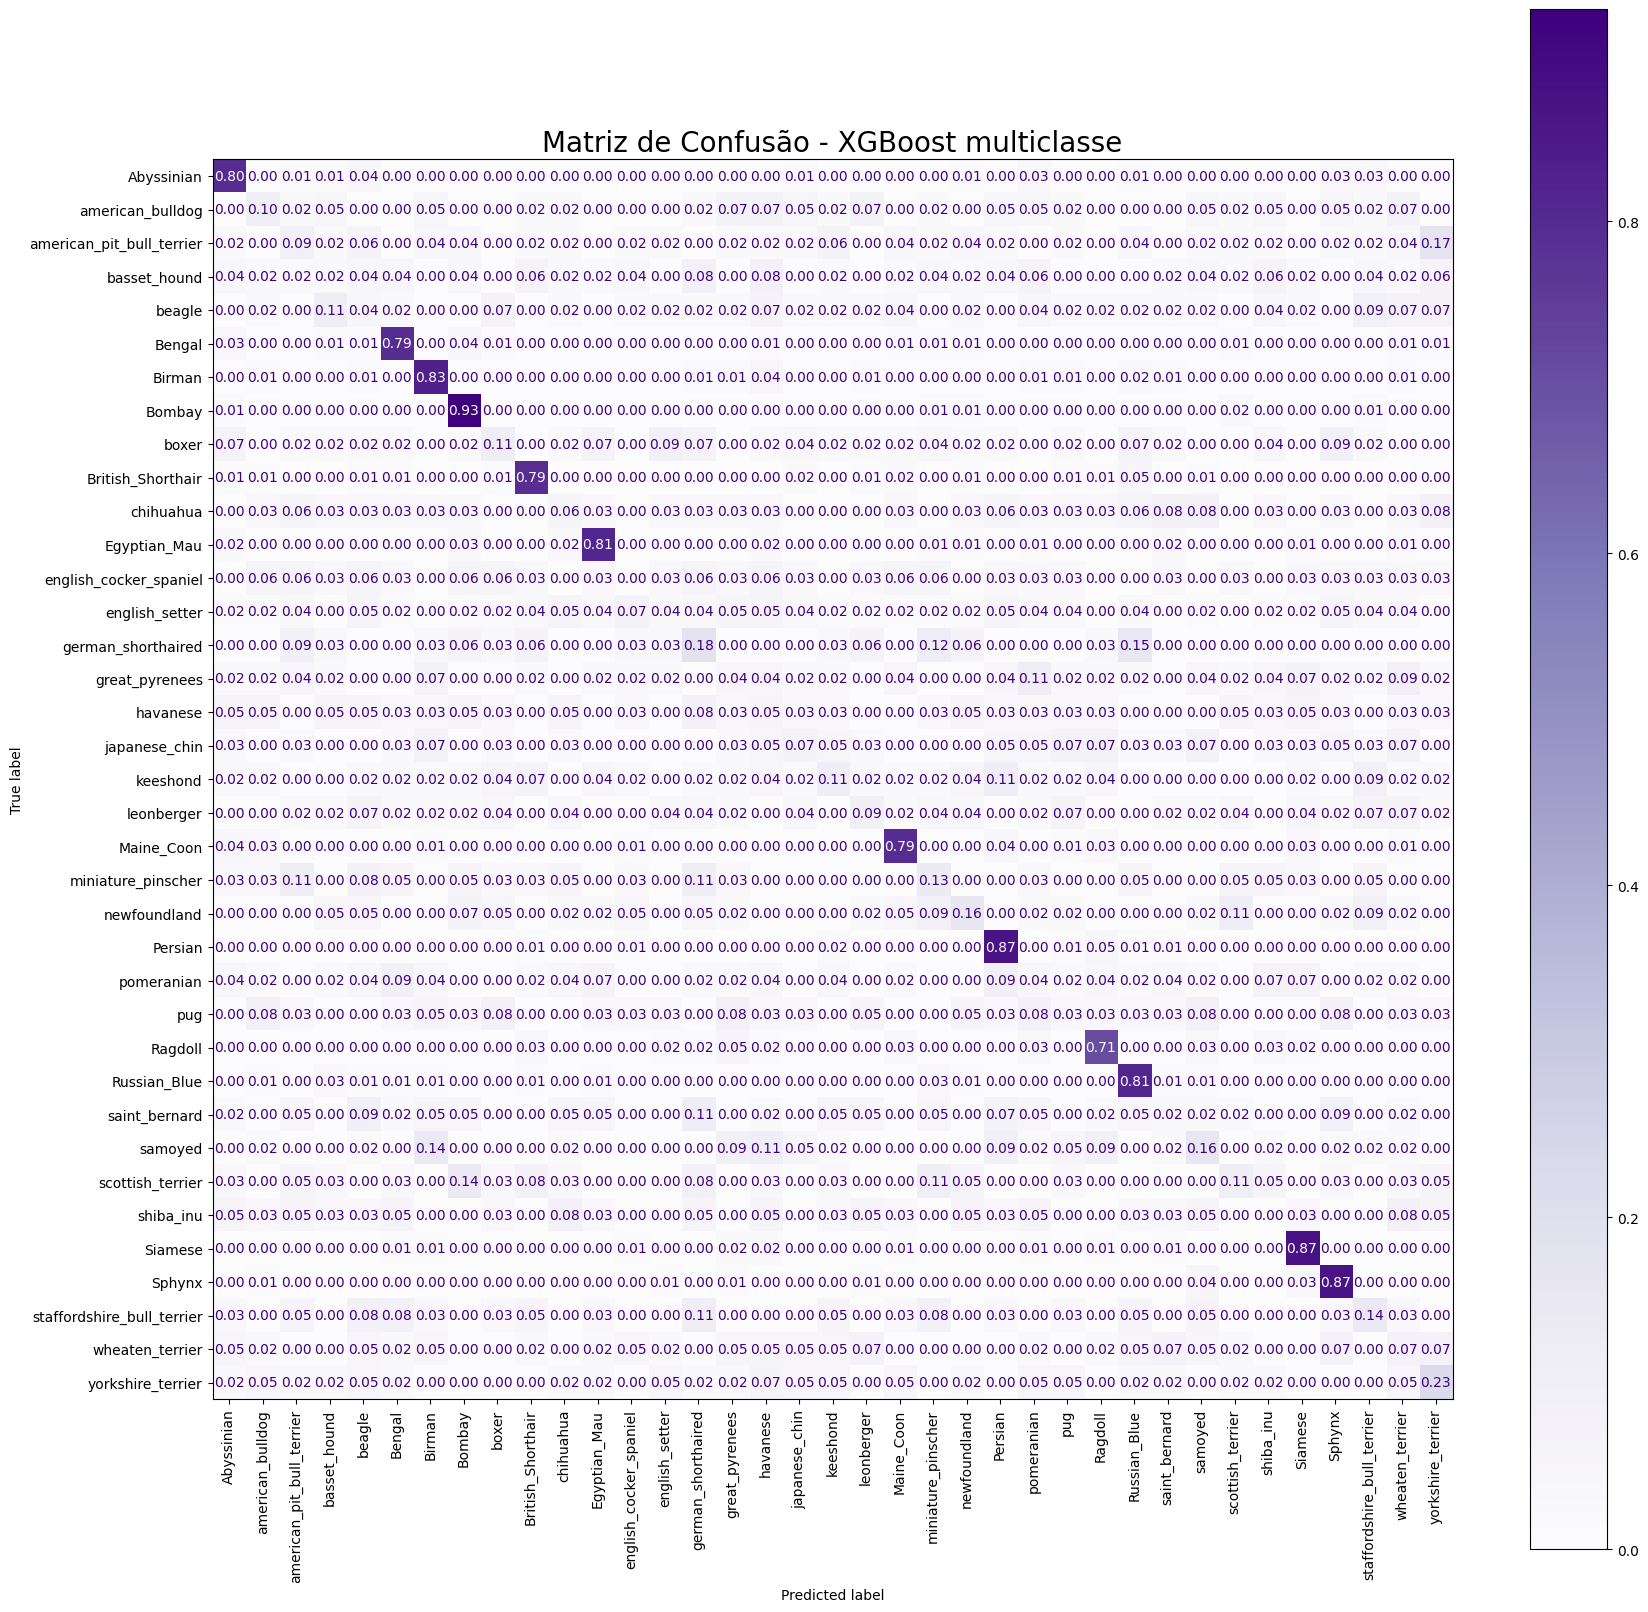

In [ ]:
# 5. Visualizar onde ele acertou mais
fig, ax = plt.subplots(figsize=(20, 20))

# Se tiver a lista de nomes, usamos ela para ficar bonito
labels_display = lista_nomes if 'lista_nomes' in locals() else le.classes_

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=labels_display,
    ax=ax,
    cmap='Purples', # Mudei para verde para diferenciar do RF
    normalize='true',
    xticks_rotation='vertical',
    values_format='.2f'
)

plt.title("Matriz de Confusão - XGBoost multiclasse", fontsize=20)
plt.show()

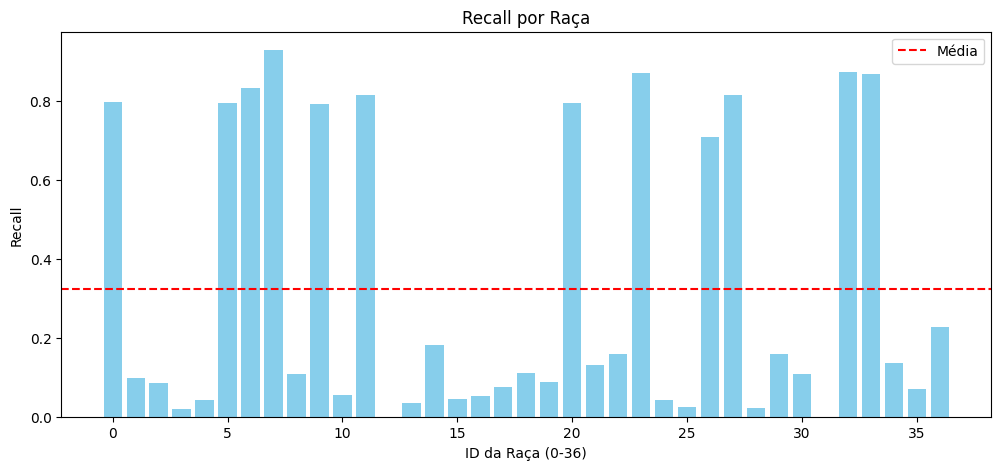

A raça mais difícil foi a ID 12 com 0.00% de recall.


In [ ]:
recalls_por_classe = recall_score(y_test, y_pred, average=None)

# Vamos plotar para ver visualmente
plt.figure(figsize=(12, 5))
plt.bar(range(len(recalls_por_classe)), recalls_por_classe, color='skyblue')
plt.xlabel('ID da Raça (0-36)')
plt.ylabel('Recall')
plt.title('Recall por Raça')
plt.axhline(y=np.mean(recalls_por_classe), color='r', linestyle='--', label='Média')
plt.legend()
plt.show()

# Dica: Para saber qual é a raça com pior recall:
pior_raca_id = np.argmin(recalls_por_classe)
print(f"A raça mais difícil foi a ID {pior_raca_id} com {recalls_por_classe[pior_raca_id]:.2%} de recall.")